In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [2]:
LZdata = np.genfromtxt('../data/exps/LZ2025/WS2024_data_hist_data.txt', skip_header=1, delimiter=' ')

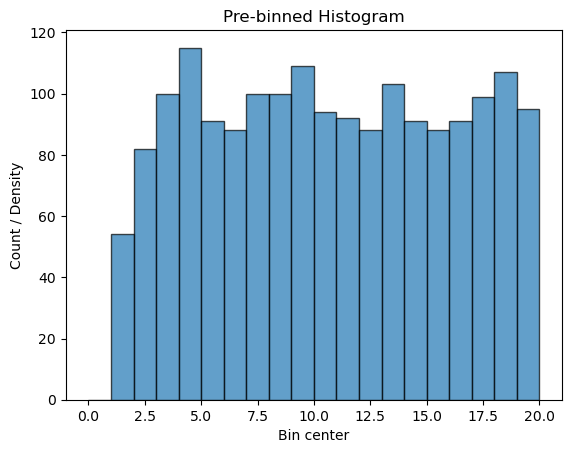

In [3]:
# Assuming your loaded array is called 'data'
bin_centers = LZdata[:, 0]   # column 1: bin centers (or edges)
heights = LZdata[:, 1]       # column 2: counts/density

# If column 1 is bin CENTERS, you need the width:
# Option A: Assume uniform width from spacing
bin_width = bin_centers[1] - bin_centers[0]  # if uniform spacing

plt.bar(bin_centers, heights, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram')
plt.show()

In [8]:
LZ_bkg_fit = np.genfromtxt('../data/exps/LZ2025/BKG_FIT_WS2024.csv', delimiter=',')

In [9]:
len(LZ_bkg_fit[:, 1])

20

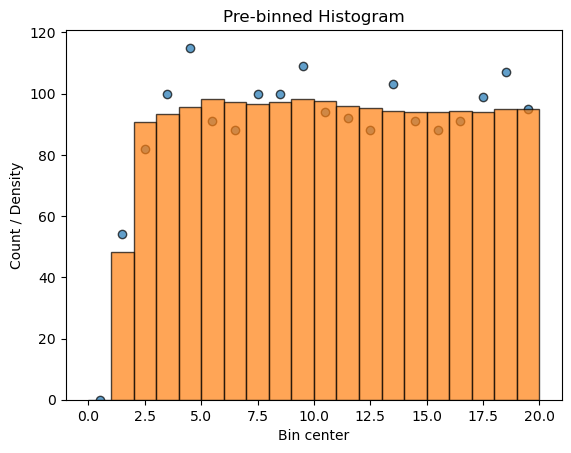

In [10]:
plt.scatter(bin_centers, heights, 
        edgecolor='black', alpha=0.7)
plt.bar(bin_centers, LZ_bkg_fit[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram')
plt.show()

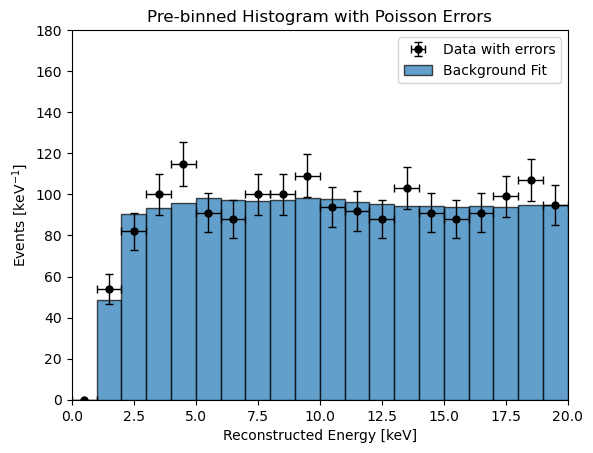

In [11]:
y_err = np.sqrt(heights)

# X-error: half bin width on each side (so bars span the full bin)
x_err = bin_width / 2

# Plot with error bars
plt.errorbar(bin_centers, heights, 
             xerr=x_err, yerr=y_err,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(bin_centers, LZ_bkg_fit[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,180)
plt.xlim(0.0,20.0)
plt.title('Pre-binned Histogram with Poisson Errors')
plt.legend()
plt.show()

#### Produce the signal 

In [12]:
from snudd import config
from snudd.targets import Electron      # the elctron target class object
from snudd.binding import binding_xe, binding_ar    # dataclass of binding energy data for xenon and argon
from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
from snudd.models  import GeneralNSI    # Generic NSI model
from snudd.targets import Nucleus       # Still need a nucleus to be declared

In [13]:
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 


In [14]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

SM_eta = 0
SM_phi = 0

sm_model = GeneralNSI(SM_matrix, SM_eta, SM_phi)

In [15]:
from snudd.resolution import Resolution, Convolver # deals with the resolution effects on the rate


In [16]:
E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered


In [17]:
min(E_Rs)*1e6

0.01

The exposure for LZ WS2024 is $3.3\,{\rm tonne-years}$ for WS2024 

In [18]:
from snudd.efficiencies import efficiency_lz_er_WS24
from snudd.resolution   import res_lz_er ## not sure if this should be updated 



In [19]:
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

sm_spec_xe = Xe_electron.spectrum(E_Rs) 

def counts_lz_ER(signal, E_Rs, E1, E2):
    exposure = 3.3 # in tn yr-1
    convolution_lz_sig= Convolver(E_Rs, signal , efficiency_lz_er_WS24, res_lz_er)
    
    return convolution_lz_sig.convolved_binned_rate(E1, E2)*exposure



In [20]:
bin_centers = LZdata[:, 0]   # column 1: bin centers (or edges)


In [21]:
counts_lz_ER(sm_spec_xe, E_Rs, (bin_centers[0]- bin_width/2)*1e-6, (bin_centers[0] + bin_width/2)*1e-6)

/home/andrew/Documents/Tools/SNuDD/snudd/resolution.py:129: UserWarning: Minimum of supplied recoil energy (0.0) is less than minimum of supplied E_prime (1e-08). Convolution may not be accurate.
  warnings.warn(f"Minimum of supplied recoil energy ({np.min(E_R)}) is less than "


(0.4918674063840352+5.391756583212688e-19j)

In [22]:
counts_sm = [
    (counts_lz_ER(
        sm_spec_xe,
        E_Rs,
        (bc - bin_width / 2) * 1e-6,
        (bc + bin_width / 2) * 1e-6
    )).real
    for bc in bin_centers
]

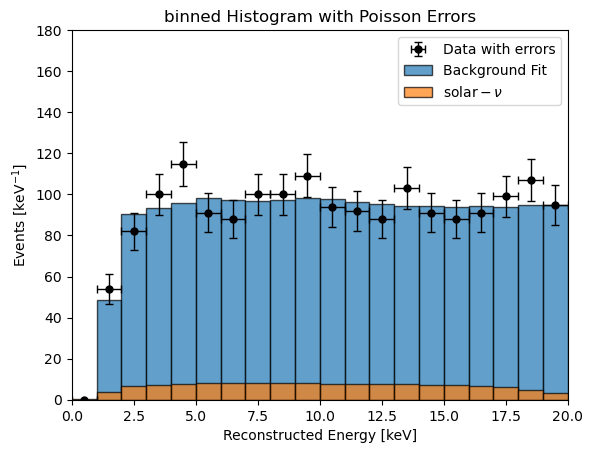

In [23]:
y_err = np.sqrt(heights)

# X-error: half bin width on each side (so bars span the full bin)
x_err = bin_width / 2

# Plot with error bars
plt.errorbar(bin_centers, heights, 
             xerr=x_err, yerr=y_err,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(bin_centers, LZ_bkg_fit[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.bar(bin_centers, counts_sm, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label=r'${\rm solar-}\nu$')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,180)
plt.xlim(0.0,20.0)
plt.title('binned Histogram with Poisson Errors')
plt.legend()
plt.show()

Note, that the total of this result is a little more than what we calculate ($151\pm9$)

In [24]:
sum(counts_sm)

132.64071362320885

This best-fit background includes the solar-$\nu$ background. Assuming out  

In [25]:
bkg_nucor = LZ_bkg_fit[:, 1] - counts_sm

We want to calculate the total rate including a NSI signal, for the ith bin

$$N_{\rm pred}^{i}(\Theta; \alpha)= (1+\alpha)N_{\rm bkg}^{i} + N^i_{\rm NSI}(\Theta)$$

where $\Theta$ is the NSI parameters and $\alpha$ is the nuisance parameter of the background fit. 

Can define the $\chi^2$ as 

$$\chi^2=2\sum^{\rm bins}_{i=1}\left[N_{\rm pred}^i-N_{\rm data}^{i} + N_{\rm data}^i\ln\left(\frac{N_{\rm data}^i}{N_{\rm pred}^i}\right)\right] + \left(\frac{\alpha}{\sigma_{\alpha}}\right)^2$$

So we need to understand the error in the background

In [26]:
# WS2024 1D fit results: (central_value, error) 
ws2024 = {
    "Pb214_beta":                  (1096, 46),
    "Kr85_Ar39_betas_det_gammas":  (236, 31),
    "Xe136_2vbb":                  (108, 16),
    "Po218_Pb212_betas":           (93.1, 10.9),
    "H3_C14":                      (62.9, 3.4),
    "Xe124_DEC":                   (19.8, 4.0),
    "Xe127_Xe125_EC":              (2.8, 0.6),
    "Rn_beta_tagging":             (0.62, 0.02) #, "solar_nu_ER": (151, 9),
}


In [27]:
def total_background(components: dict):
    values = np.array([v for v, _ in components.values()])
    errors = np.array([e for _, e in components.values()])
    total_val = values.sum()
    total_err = np.sqrt((errors**2).sum())  # quadrature sum
    return total_val, total_err

total_val_24, total_err_24 = total_background(ws2024)

print(f"Total background: {total_val_24:.1f} ± {total_err_24:.1f}")

Total background: 1619.2 ± 59.0


In [28]:
59.0/1619.2  

0.03643774703557312

I will assume that this uncertainty is even for each bin, $\%3.7$

In [29]:
def poisson_chi2(N_nu: np.ndarray, N_bkg: np.ndarray, N_data: np.ndarray, alpha: float = 0.0, sigma_alpha: float = 1.0):
    """
    Compute the Poissonlikelihood-based chi-squared (Cash statistic).

    chi^2 = 2 * sum_i [ N_pred^i - N_data^i + N_data^i * ln(N_data^i / N_pred^i) ] + (alpha / sigma_alpha)^2

    Parameters
    ----------
    N_nu : np.ndarray
        Number of neutrino events in each bin (must be non-negative)
    N_bkg : np.ndarray
        Number of background events in each bin (must be non-negative)
    N_data : np.ndarray
        Observed number of events in each bin (must be non-negative)
    alpha : float, optional
        Nuisance parameter (default: 0.0)
    sigma_alpha : float, optional
        Uncertainty on the nuisance parameter (default: 1.0)

    Returns
    -------
    float
        The chi-squared value
    """
    N_pred = np.atleast_1d(N_nu + (1+alpha)*N_bkg)
    N_data = np.atleast_1d(N_data)

    assert len(N_pred) == len(N_data), "N_pred and N_data must have the same length"

    # Handle edge cases:
    # 1. When N_data = 0, the term N_data * ln(N_data / N_pred) -> 0 (limit as x->0 of x*ln x = 0)
    # 2. When N_pred = 0, the log term is problematic - skip these bins
    # 3. Use np.log to compute ln(N_data / N_pred) = ln(N_data) - ln(N_pred)

    valid_mask = N_pred > 0

    if not np.any(valid_mask):
        return np.inf  # all predictions are invalid

    N_pred_valid = N_pred[valid_mask]
    N_data_valid = N_data[valid_mask]

    # Compute term = N_pred - N_data + N_data * ln(N_data / N_pred)
    # For zero bins where N_data = 0, the ln term contributes zero
    term = N_pred_valid - N_data_valid + N_data_valid * (
        np.log(N_data_valid + 1e-300) - np.log(N_pred_valid)  # handles N_data = 0 naturally
    )

    # Sum over bins and multiply by 2
    chi2 = 2.0 * np.sum(term)

    # Add the nuisance parameter penalty term
    chi2 += (alpha / sigma_alpha)**2

    return chi2

In [30]:
poisson_chi2(counts_sm, bkg_nucor, heights)

12.452759803304035

Do a 1D scan 

In [37]:
eps_space = np.geomspace(1e-1, 0.5, 10)
eta = 0.0 # therefore in the proton-neutron plane
phi = np.pi/2 # therefore in the electron direction   




In [38]:
import tqdm as tqdm 

In [39]:
from snudd.nsi import utils


In [40]:
def set_NSI_params(eps, eta, phi):
    
    eps_matrix = np.array([[0., 1.0, 0.], [1.0, 0.0, 0.], [0., 0, 0.0]]) * eps # eps_{e\mu} can change this structure 
    eps_matrix = utils.eps_matrix_sym(eps_matrix)
    nsi_model = GeneralNSI(eps_matrix, eta, phi)
    
    return nsi_model

In [41]:
from tqdm import tqdm


In [42]:
# Initialize a 2D array: shape (n_eps, n_bins)
counts_all = np.zeros((len(eps_space), len(bin_centers)))

for i, eps in enumerate(tqdm(eps_space, desc="Processing eps values")):
    NSI_eps_tmp = eps
    NSI_eta_tmp = eta  # fixed as zero
    NSI_phi_tmp = phi  # fixed as zero

    nsi_temp = set_NSI_params(NSI_eps_tmp, NSI_eta_tmp, NSI_phi_tmp)
    Xe_electron.update_model(nsi_temp)
    Xe_electron.prepare_density()

    signal_temp = Xe_electron.spectrum(E_Rs) 
    # Compute binned counts for this eps value
    counts_all[i, :] = np.array([
        (counts_lz_ER(
            np.array(signal_temp),
            E_Rs,
            (bc - bin_width / 2) * 1e-6,
            (bc + bin_width / 2) * 1e-6
        )).real
        for bc in bin_centers
    ])


Processing eps values:   0%|          | 0/10 [00:00<?, ?it/s]/home/andrew/Documents/Tools/SNuDD/snudd/resolution.py:129: UserWarning: Minimum of supplied recoil energy (0.0) is less than minimum of supplied E_prime (1e-08). Convolution may not be accurate.
  warnings.warn(f"Minimum of supplied recoil energy ({np.min(E_R)}) is less than "
Processing eps values: 100%|██████████| 10/10 [00:31<00:00,  3.13s/it]


In [43]:
counts_all[1, :]

array([0.54189767, 4.25965842, 7.31547686, 7.99270503, 8.31497952,
       8.78071021, 8.9836122 , 8.94400507, 8.85200512, 8.74515059,
       8.62732932, 8.50508074, 8.38260286, 8.25482955, 8.09830601,
       7.85361226, 7.40767714, 6.59847286, 5.29442645, 3.5917412 ])

In [44]:
chi2_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    chi2_values[i] = poisson_chi2(counts_all[i, :], bkg_nucor, heights)

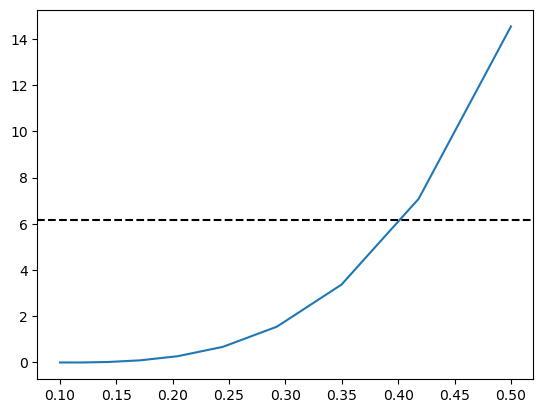

In [47]:
plt.plot(eps_space, chi2_values-np.min(chi2_values))
plt.axhline(6.18, color='k', ls='--')


To marginalize over the nuisance $\alpha$ I need to minimize the $\chi^2$ w.r.t. $\alpha$ 

In [48]:
from scipy.optimize import minimize_scalar


In [49]:
minimize_scalar(fun = lambda a: poisson_chi2(counts_all[i, :], bkg_nucor, heights, alpha=a, sigma_alpha=0.0364), bounds=(-5, 5), method='bounded')

 message: Solution found.
 success: True
  status: 0
     fun: 19.174042762133016
       x: -0.06050597359463776
     nit: 13
    nfev: 13

In [50]:
chi2_alpha_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    result = minimize_scalar(fun = lambda a: poisson_chi2(counts_all[i, :], bkg_nucor, heights, alpha=a, sigma_alpha=0.0364), bounds=(-5, 5), method='bounded')
    chi2_alpha_values[i] = result.fun

Text(0, 0.5, '$\\chi^2 - \\chi^2_{\\rm min}$')

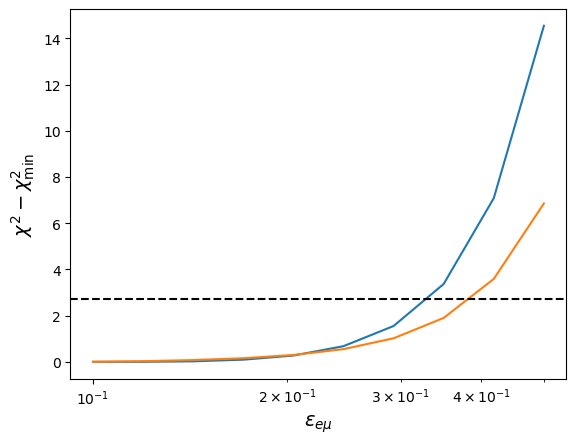

In [55]:
plt.semilogx(eps_space, chi2_values-np.min(chi2_values))
plt.semilogx(eps_space, chi2_alpha_values-np.min(chi2_alpha_values))

plt.axhline(2.71, color='k', ls='--')

plt.xlabel(r'$\epsilon_{e\mu}$', size=14)
plt.ylabel(r'$\chi^2 - \chi^2_{\rm min}$', size=14)